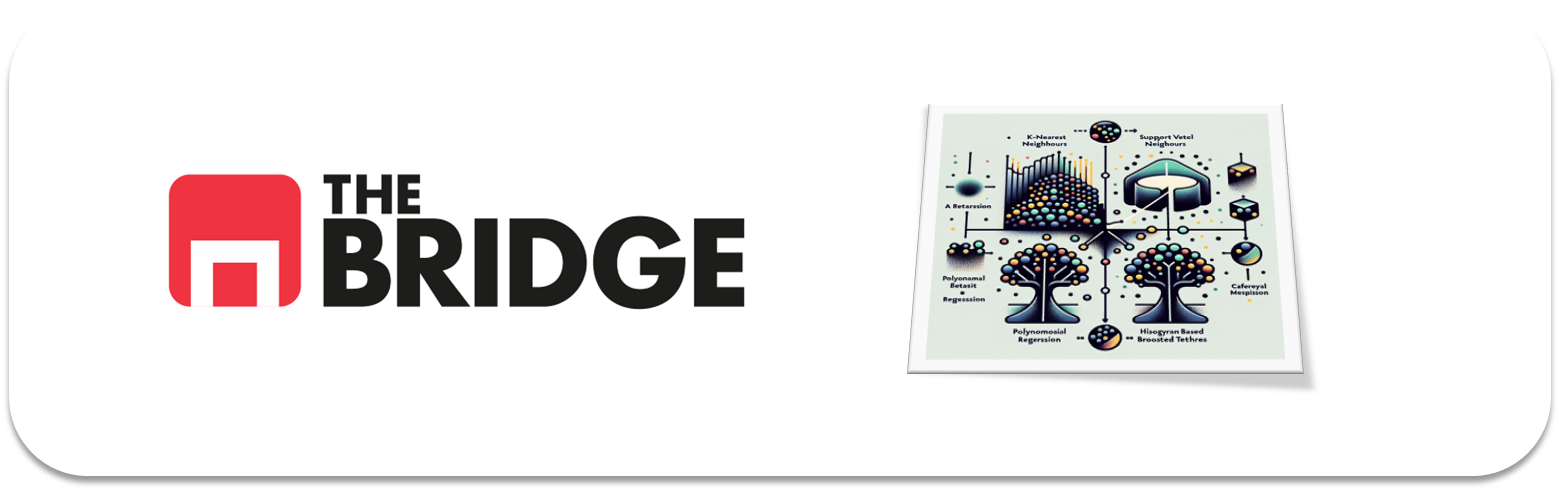

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
import bootcampviztools as bt


from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              mean_absolute_percentage_error, mean_absolute_error)
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [12]:
df = pd.read_csv("./data/wines_dataset.csv", sep="|")
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.210,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.160,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.180,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.260,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.630,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red
5,5.7,0.265,0.28,6.90,0.036,46.0,150.0,0.99299,3.36,0.44,10.8,7,white
6,6.6,0.210,0.31,11.40,0.039,46.0,165.0,0.99795,3.41,0.44,9.8,7,white
7,6.7,0.310,0.30,2.10,0.038,18.0,130.0,0.99280,3.36,0.63,10.6,6,white
8,8.9,0.750,0.14,2.50,0.086,9.0,30.0,0.99824,3.34,0.64,10.5,5,red
9,7.5,0.420,0.20,1.40,0.060,15.0,168.0,0.99440,3.06,0.40,9.4,6,white


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [14]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [15]:
# dos targets, uno para cada problema

target_clf = "quality"
target_reg = "alcohol"

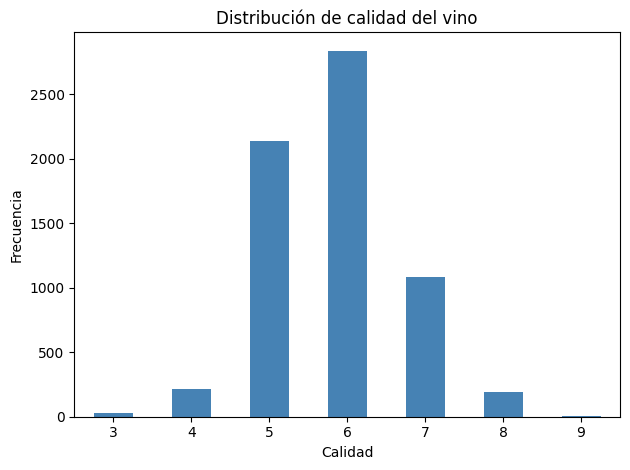

quality
3    0.005
4    0.033
5    0.329
6    0.437
7    0.166
8    0.030
9    0.001
Name: proportion, dtype: float64


In [16]:
df[target_clf].value_counts().sort_index().plot(kind="bar", color="steelblue")
plt.title("Distribución de calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df[target_clf].value_counts(normalize=True).sort_index().round(3))

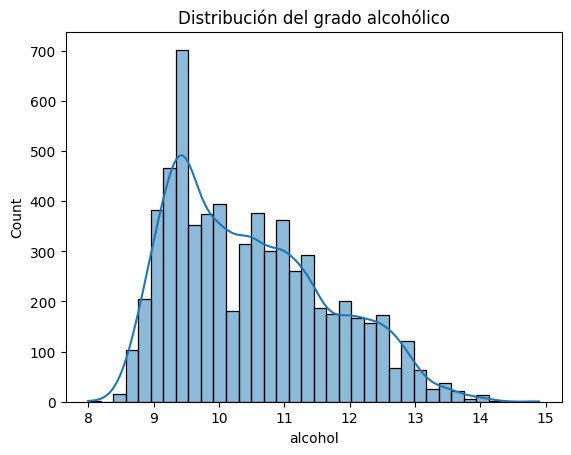

In [17]:
# distribución del target de regresión

sns.histplot(df[target_reg], kde=True)
plt.title("Distribución del grado alcohólico")
plt.show()

**Clasificación**: problema multiclase (valores de calidad del 3 al 9) fuertemente desequilibrado – 
las clases 5 y 6 concentran la mayoría de los vinos. Habrá que aplicar técnicas de balanceo 
y la métrica objetivo es el **recall medio**.

**Regresión**: distribución del grado alcohólico razonablemente centrada, sin colas extremas. 
La métrica objetivo es el **MAPE** (error porcentual medio), ya que el negocio quiere 
equivocarse lo menos posible en términos relativos.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [18]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)


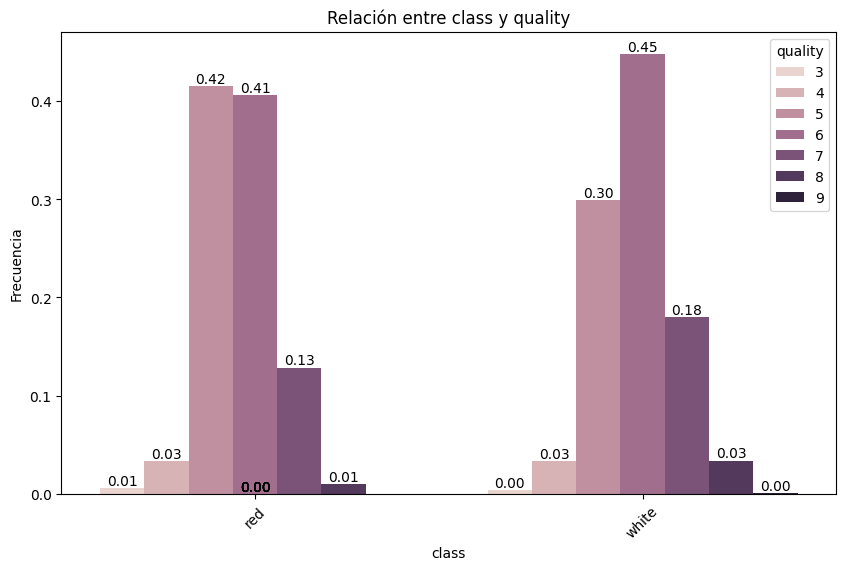

In [19]:
# MiniEDA clasificación – la categórica "class" contra el target

bt.plot_categorical_relationship_fin(train_set, "class", target_clf, show_values=True, relative_freq=True)

In [20]:
features_num_clf = [col for col in train_set.columns if col != "class" and col != target_clf]
print(len(features_num_clf))

11


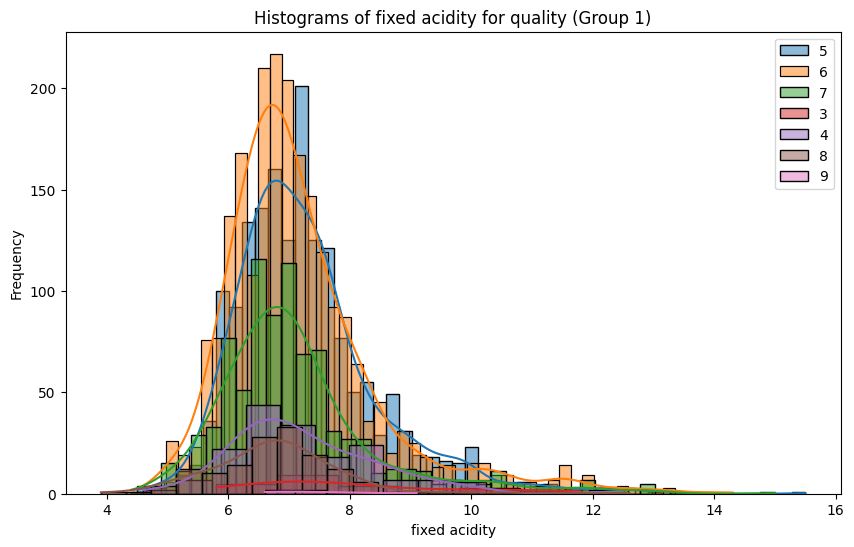

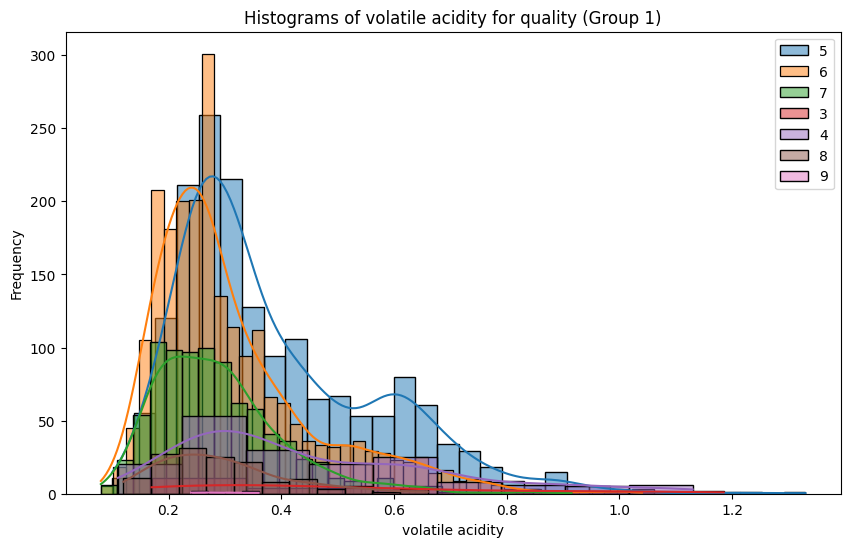

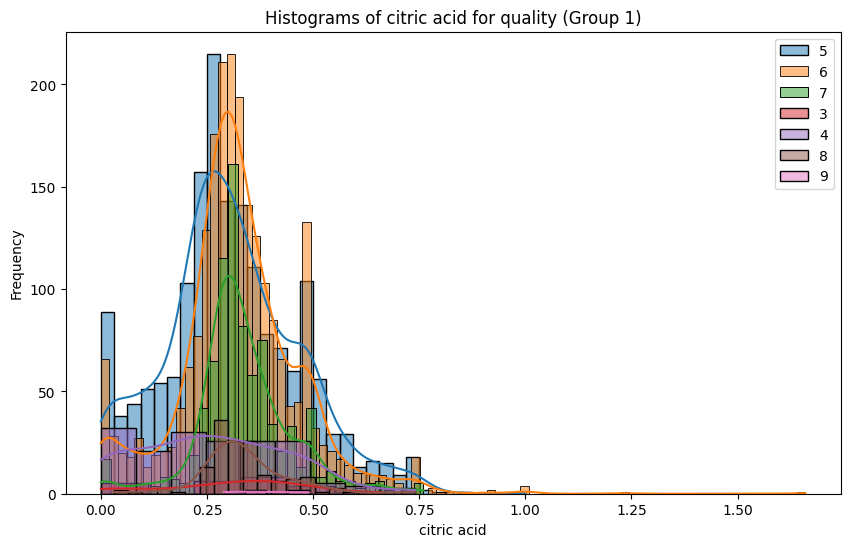

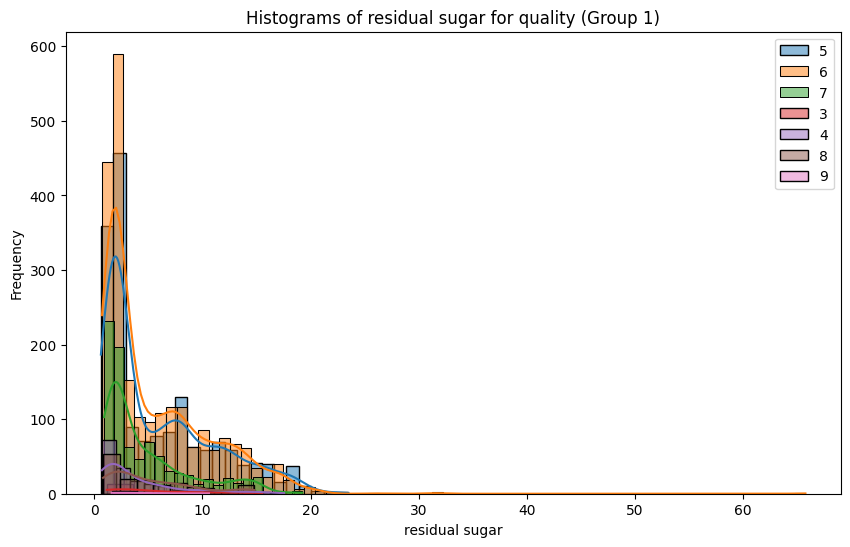

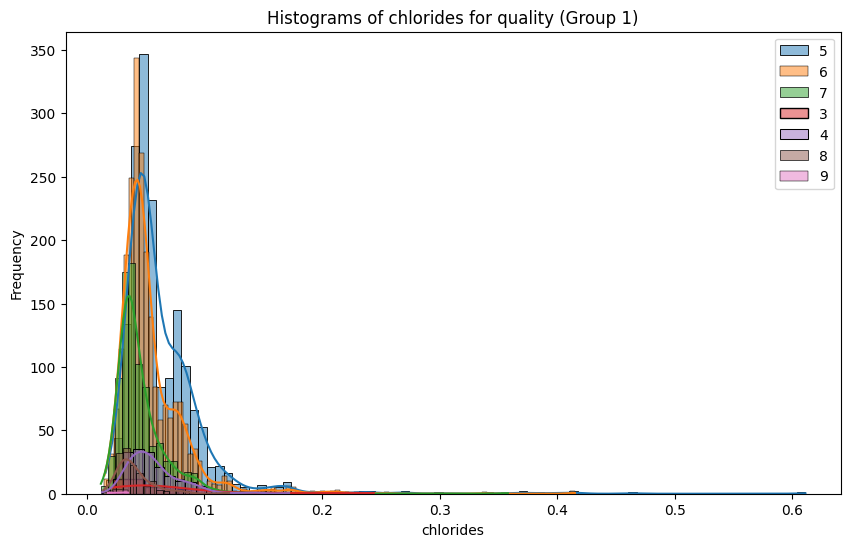

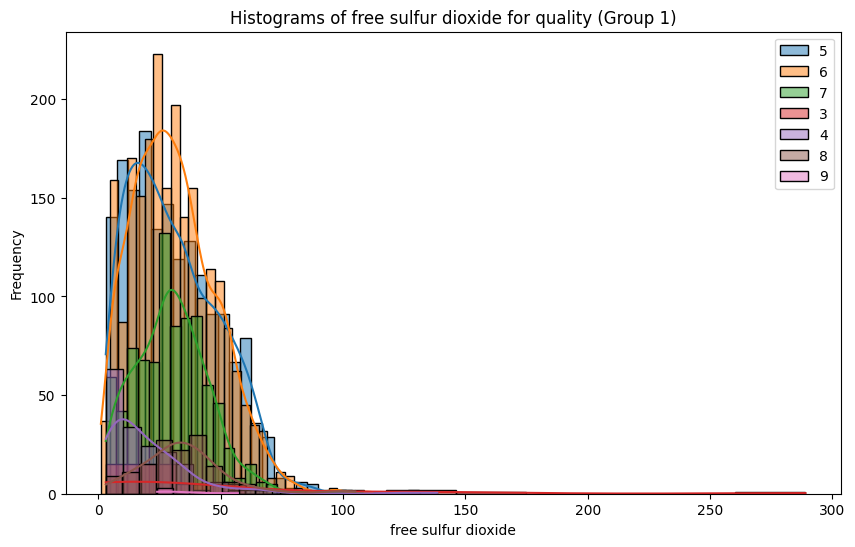

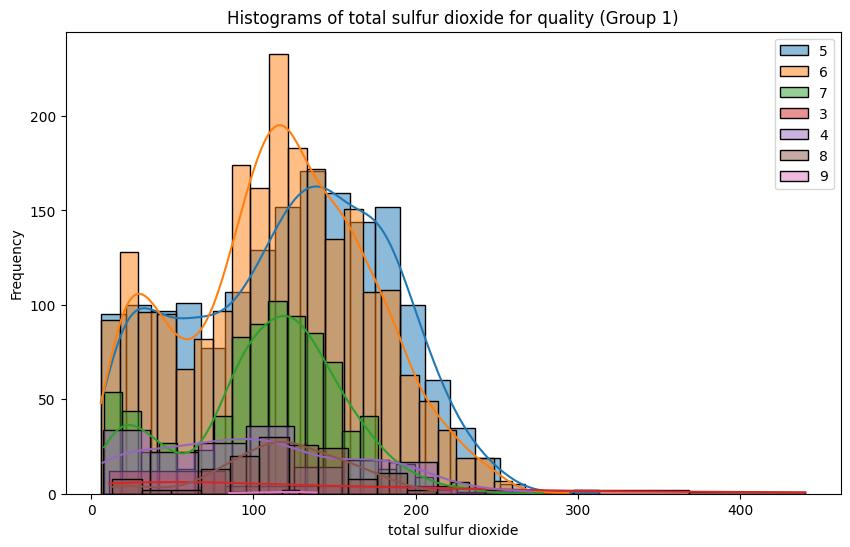

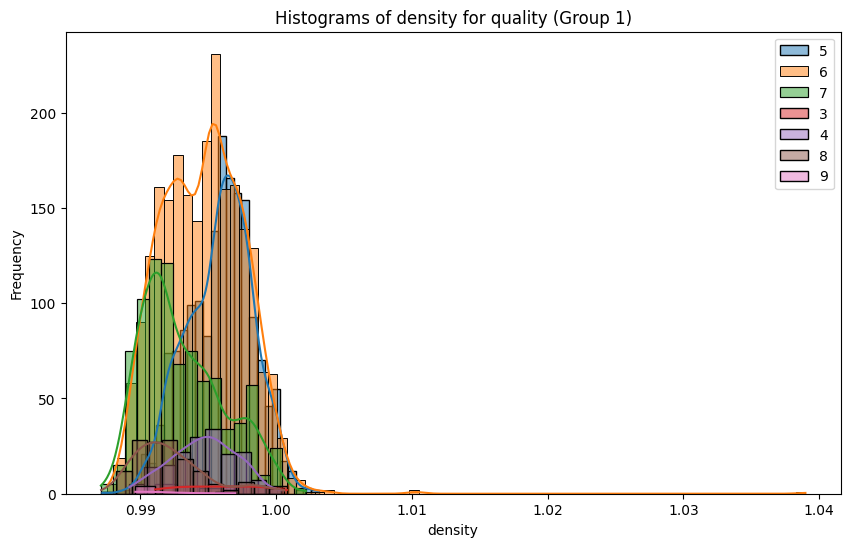

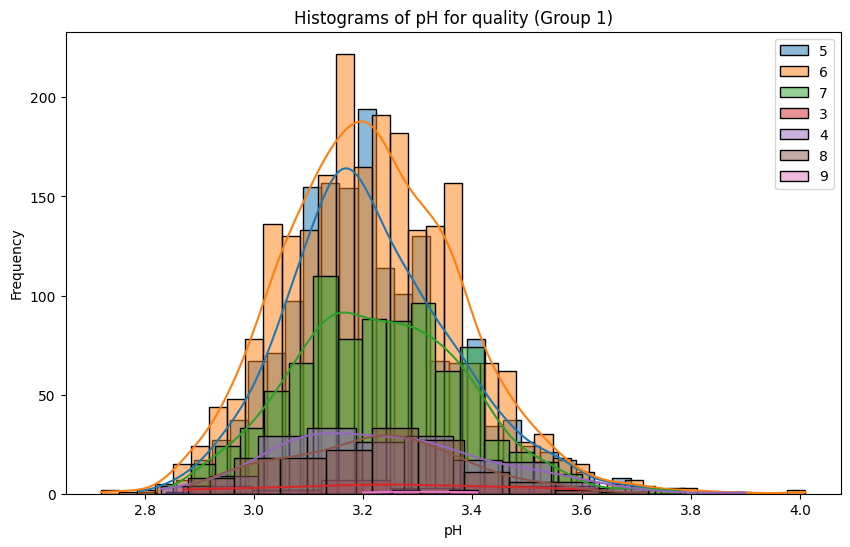

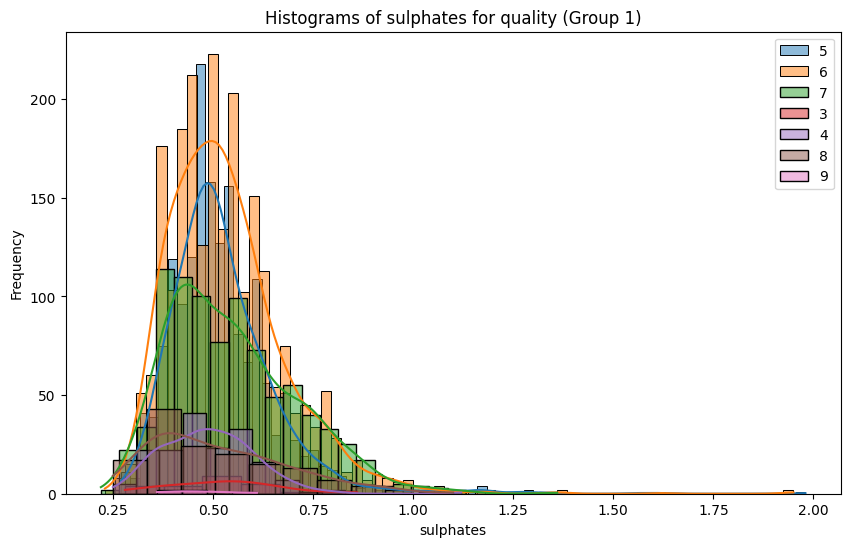

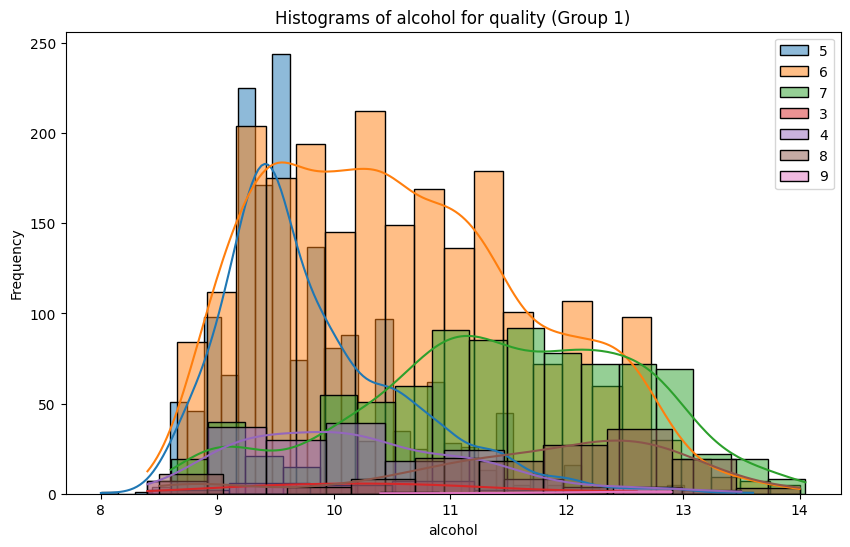

In [21]:
# histogramas de cada numérica separados por clase de calidad

for col in features_num_clf:
    bt.plot_grouped_histograms(train_set, cat_col=target_clf, num_col=col, group_size=train_set[target_clf].nunique())

In [22]:
features_cat_clf = ["class"]

In [23]:
# correlación de las numéricas con el target de clasificación – para ver cuáles aportan

corr_clf = np.abs(train_set[features_num_clf].corrwith(train_set[target_clf]))
corr_clf.sort_values(ascending=False)

alcohol                 0.450403
density                 0.305107
volatile acidity        0.255368
chlorides               0.197389
citric acid             0.096020
fixed acidity           0.071698
sulphates               0.052398
total sulfur dioxide    0.050816
free sulfur dioxide     0.039678
residual sugar          0.039630
pH                      0.011918
dtype: float64

In [24]:
# me quedo las que superan un umbral mínimo de correlación

r_min_clf = 0.10
features_num_clf_1 = corr_clf[corr_clf > r_min_clf].index.to_list()
features_num_clf_2 = [col for col in features_num_clf if col not in features_num_clf_1]

print("Features seleccionadas:", features_num_clf_1)
print("Features descartadas:", features_num_clf_2)

Features seleccionadas: ['volatile acidity', 'chlorides', 'density', 'alcohol']
Features descartadas: ['fixed acidity', 'citric acid', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'pH', 'sulphates']


In [25]:
# con tan pocas features el modelo va a sufrir – me quedo todas las numéricas

features_num_clf_1 = features_num_clf.copy()
features_num_clf_2 = []

print("Features para clasificación:", features_num_clf_1)

Features para clasificación: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [26]:
# convertimos "class" a numérica – white=1, red=0

train_set["class"] = (train_set["class"] == "white").astype(int)
test_set["class"] = (test_set["class"] == "white").astype(int)

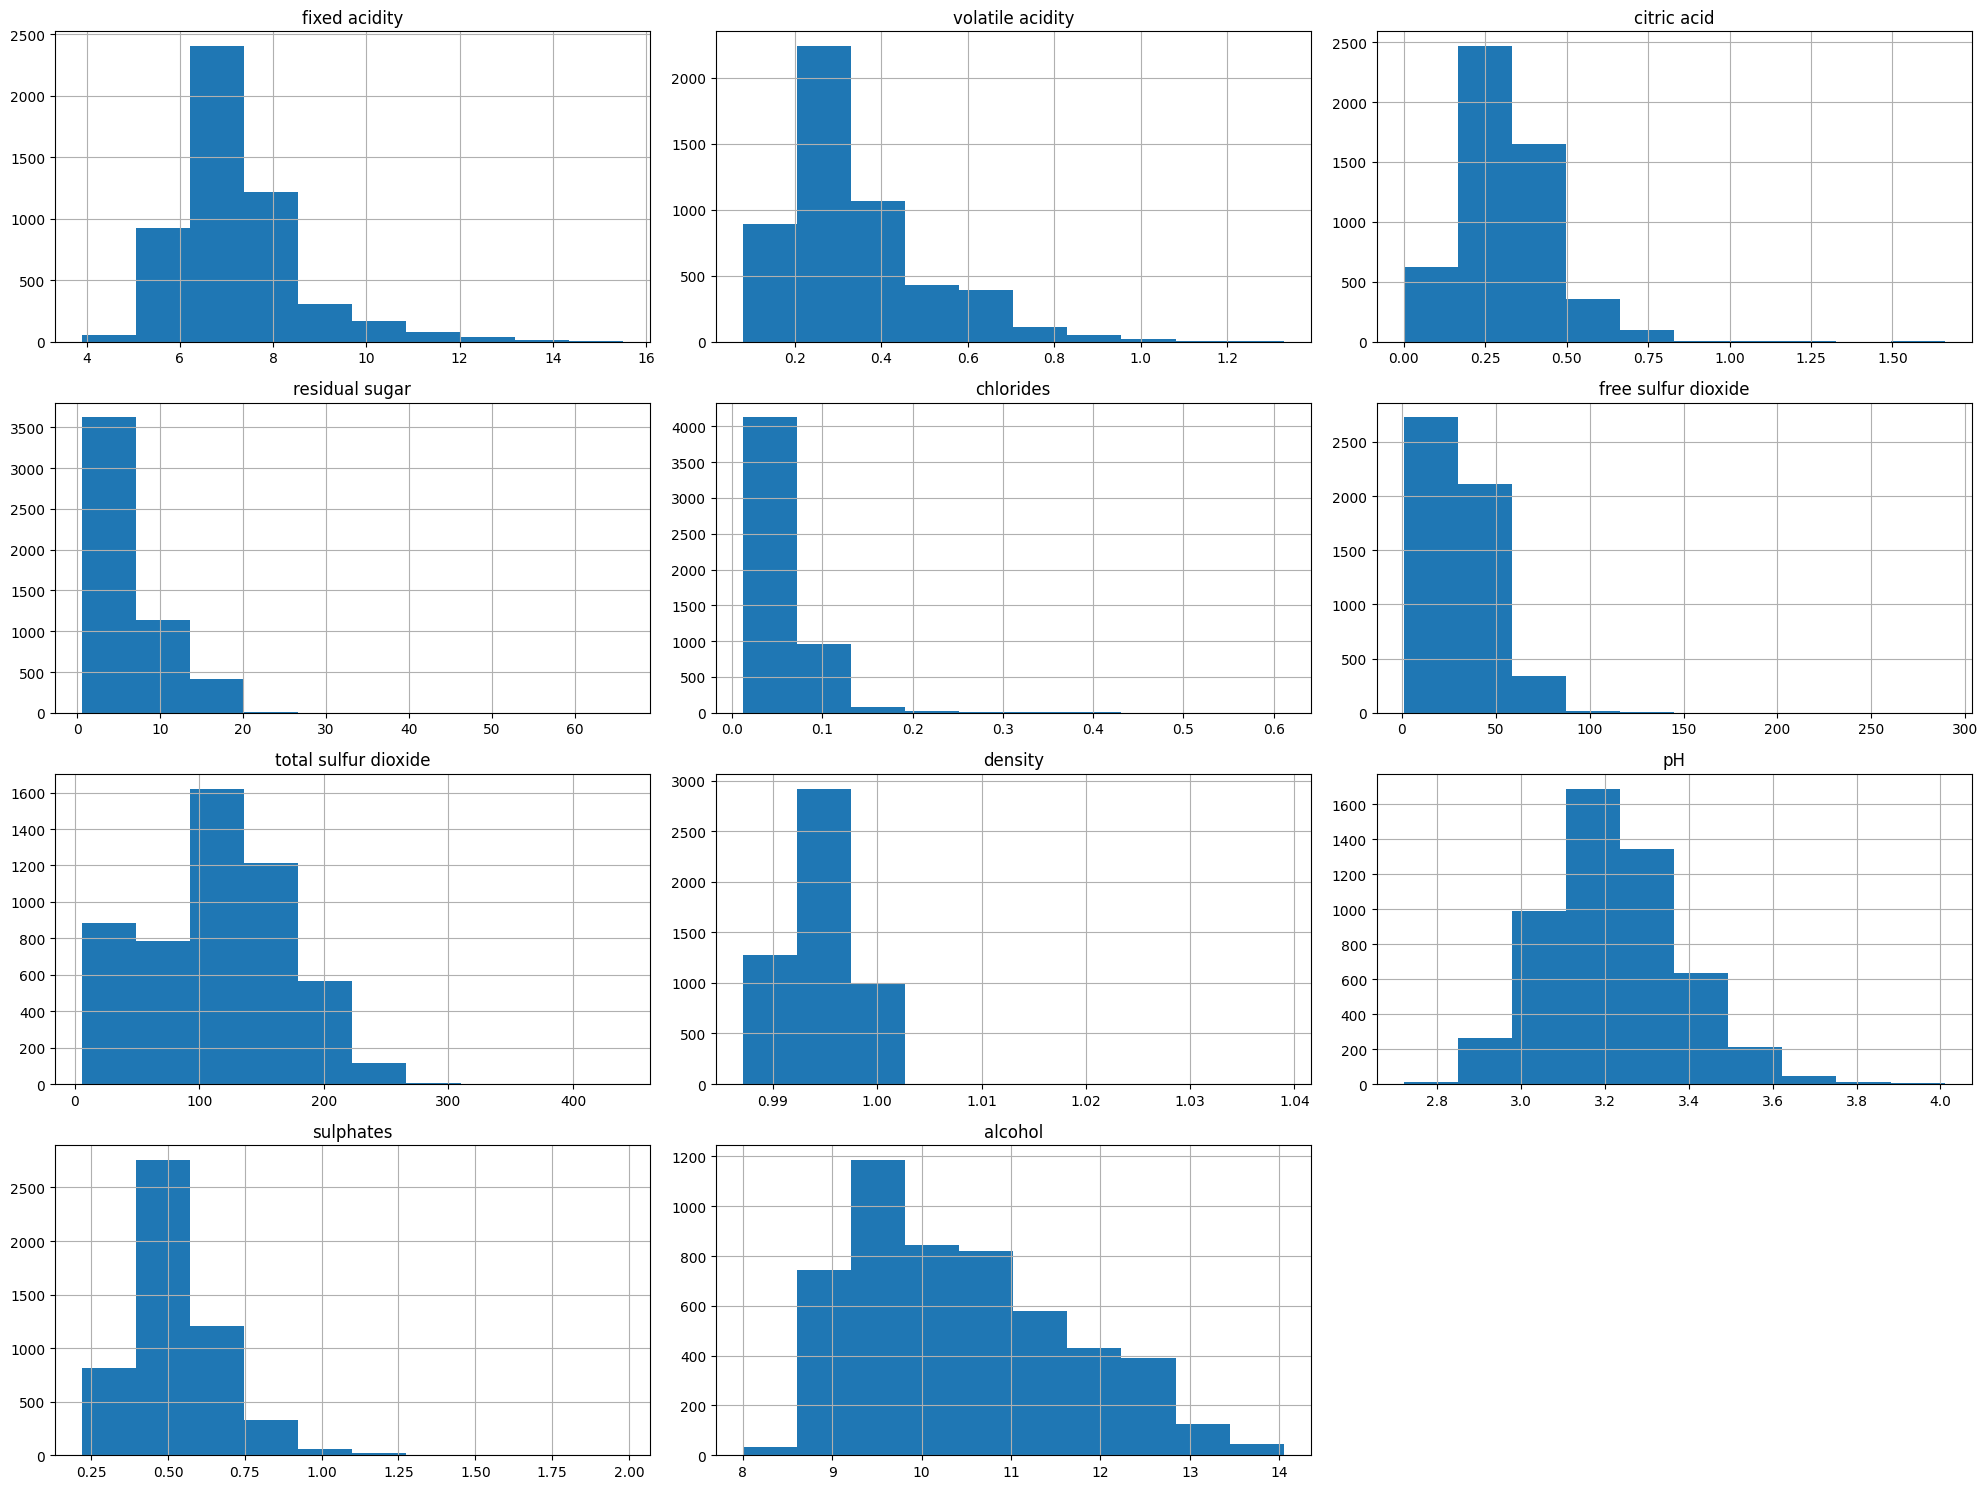

In [27]:
# histogramas para ver qué necesita transformación logarítmica

train_set[features_num_clf_1].hist(figsize=(20, 15))
plt.tight_layout()
plt.show()

In [28]:
features_to_transform = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "sulphates"
]

train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

for col in features_to_transform:
    desplaza = 0
    if train_set_scaled[col].min() <= 0:
        desplaza = int(abs(train_set_scaled[col].min())) + 1
    train_set_scaled[col] = np.log(train_set_scaled[col] + desplaza)
    test_set_scaled[col] = np.log(test_set_scaled[col] + desplaza)

In [29]:
# escalamos las numéricas – sin tocar alcohol porque es target de regresión

features_num_reg = features_num_clf_1.copy()
features_num_reg.remove("alcohol")

scaler = StandardScaler()
train_set_scaled[features_num_reg] = scaler.fit_transform(train_set_scaled[features_num_reg])
test_set_scaled[features_num_reg] = scaler.transform(test_set_scaled[features_num_reg])

In [30]:
# para clasificación también escalamos alcohol

train_set_scaled_clf = train_set_scaled.copy()
test_set_scaled_clf = test_set_scaled.copy()

train_set_scaled_clf["alcohol"] = scaler.fit_transform(train_set_scaled_clf[["alcohol"]])
test_set_scaled_clf["alcohol"] = scaler.transform(test_set_scaled_clf[["alcohol"]])


In [31]:
# generamos X,y para clasificación

y_train_clf = train_set[target_clf]
y_test_clf = test_set[target_clf]

X_train_clf = train_set_scaled_clf[features_cat_clf + features_num_clf_1]
X_test_clf = test_set_scaled_clf[features_cat_clf + features_num_clf_1]

In [32]:
# baseline KNN – probamos con dos valores de K como pide el enunciado

knn_clf_5 = KNeighborsClassifier(n_neighbors=5)
knn_clf_11 = KNeighborsClassifier(n_neighbors=11)

for k, modelo in zip([5, 11], [knn_clf_5, knn_clf_11]):
    metrica = np.mean(cross_val_score(modelo, X_train_clf, y_train_clf, cv=5, scoring="balanced_accuracy"))
    print(f"KNN k={k}: {metrica:.4f}")

KNN k=5: 0.2626
KNN k=11: 0.2417


In [33]:
# comparativa con más modelos – el multiclase es duro, veremos

lr_clf = LogisticRegression(max_iter=10000, class_weight="balanced")
rf_clf = RandomForestClassifier(max_depth=10, random_state=42, class_weight="balanced")
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lgb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose=-1,
                          class_weight="balanced", n_jobs=-1)

modelos_clf = {
    "KNN_5": knn_clf_5,
    "KNN_11": knn_clf_11,
    "Logistic": lr_clf,
    "RandomF": rf_clf,
    "XGBoost": xgb_clf,
    "LightGBM": lgb_clf
}

for nombre, modelo in modelos_clf.items():
    metrica = np.mean(cross_val_score(modelo, X_train_clf, y_train_clf, cv=5, scoring="balanced_accuracy"))
    print(f"{nombre}: {metrica:.4f}")

KNN_5: 0.2626
KNN_11: 0.2417
Logistic: 0.3845
RandomF: 0.3320


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/jorge/Documentos/Bootcamp/thebridge-ds/venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/jorge/Documentos/Bootcamp/thebridge-ds/venv/lib/python3.12/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/home/jorge/Documentos/Bootcamp/thebridge-ds/venv/lib/python3.12/site-packages/xgboost/sklearn.py", line 1761, in fit
    raise ValueError(
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got [3 4 5 6 7 8 9]


### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [34]:
# MiniEDA regresión – correlación de las numéricas con el grado alcohólico

features_cat_reg = ["class"]
features_num_reg_all = [col for col in train_set.columns if col != "class" and col != target_reg]

corr_reg = np.abs(train_set[features_num_reg_all].corrwith(train_set[target_reg]))
corr_reg.sort_values(ascending=False)

density                 0.682345
quality                 0.450403
residual sugar          0.357459
total sulfur dioxide    0.272970
chlorides               0.260508
free sulfur dioxide     0.188460
pH                      0.116497
fixed acidity           0.091964
volatile acidity        0.036041
citric acid             0.005690
sulphates               0.000412
dtype: float64

In [35]:
r_min_reg = 0.10
features_num_reg_1 = corr_reg[corr_reg > r_min_reg].index.to_list()
features_num_reg_2 = [col for col in features_num_reg_all if col not in features_num_reg_1]

print("Seleccionadas:", features_num_reg_1)
print("Descartadas:", features_num_reg_2)

Seleccionadas: ['residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'quality']
Descartadas: ['fixed acidity', 'volatile acidity', 'citric acid', 'sulphates']


In [36]:
# free sulfur dioxide correla fuerte con total sulfur dioxide – la quitamos

features_num_reg_1.remove("free sulfur dioxide")
features_num_reg_2.append("free sulfur dioxide")

print("Seleccionadas:", features_num_reg_1)

Seleccionadas: ['residual sugar', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'quality']


In [37]:
# generamos X,y para regresión

y_train_reg = train_set[target_reg]
y_test_reg = test_set[target_reg]

X_train_reg = train_set_scaled[features_cat_reg + features_num_reg_1]
X_test_reg = test_set_scaled[features_cat_reg + features_num_reg_1]

In [38]:
# comparativa de tres modelos con validación cruzada – MAPE como métrica

rf_reg = RandomForestRegressor(max_depth=10, random_state=42)
xgb_reg = XGBRegressor(max_depth=10, random_state=42)
lgb_reg = LGBMRegressor(max_depth=10, random_state=42, verbose=-1)

modelos_reg = {
    "RandomF": rf_reg,
    "XGBoost": xgb_reg,
    "LightGBM": lgb_reg
}

for nombre, modelo in modelos_reg.items():
    metrica = np.mean(cross_val_score(modelo, X_train_reg, y_train_reg, cv=5,
                                      scoring="neg_mean_absolute_percentage_error"))
    print(f"{nombre}: {abs(metrica):.4f}")

RandomF: 0.0362
XGBoost: 0.0314
LightGBM: 0.0360


In [39]:
# ajuste de hiperparámetros del ganador – XGBoost

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.1, 0.5],
    "max_depth": [5, 10]
}

xgb_reg = XGBRegressor(random_state=42)

xgb_grid_reg = GridSearchCV(xgb_reg,
                              param_grid=param_grid,
                              cv=5,
                              scoring="neg_mean_absolute_percentage_error",
                              n_jobs=-1)

xgb_grid_reg.fit(X_train_reg, y_train_reg)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.5], 'max_depth': [5, 10], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_percentage_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [40]:
print("Mejores hiperparámetros:", xgb_grid_reg.best_params_)
print("Mejor score CV:", abs(round(xgb_grid_reg.best_score_, 4)))

Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}
Mejor score CV: 0.0307


In [41]:
# evaluación contra test

y_pred_reg = xgb_grid_reg.best_estimator_.predict(X_test_reg)

print(f"MAPE: {mean_absolute_percentage_error(y_test_reg, y_pred_reg):.4f}")
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_reg):.4f}")

MAPE: 0.0280
MAE: 0.2978


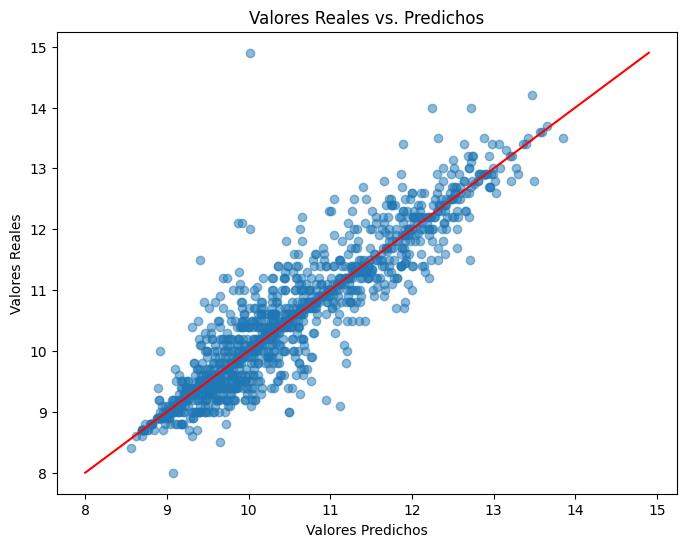

In [42]:
# análisis de errores – reales vs predichos

def plot_predictions_vs_actual(y_real, y_pred):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_real, alpha=0.5)
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")
    max_val = max(max(y_real), max(y_pred))
    min_val = min(min(y_real), min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r')
    plt.title("Valores Reales vs. Predichos")
    plt.show()

plot_predictions_vs_actual(y_test_reg, y_pred_reg)

El modelo alcanza un MAPE de ~3%, lo que significa que se equivoca de media un 3% sobre el grado 
alcohólico real — resultado más que aceptable para el objetivo de negocio. Los puntos se agrupan 
razonablemente cerca de la diagonal, aunque hay algo más de dispersión en los extremos (vinos 
muy poco o muy alcohólicos), donde el modelo tiene menos ejemplos de entrenamiento.